# 04 · Remaining-useful-life with calibrated intervals

For slowly-evolving faults (drift, valve stick), the operator wants more than *yes/no* — they want **how long until I must intervene**, with uncertainty bounds.

In [1]:
import sensorlab  # set OMP env vars before torch/xgboost load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})


In [2]:
from sensorlab.data import (load_dataset, SyntheticTEPConfig, Standardizer,
                           sliding_windows, train_val_test_split_by_run)
from sensorlab.diagnosis import window_features
from sensorlab.rul import QuantileRUL, build_rul_targets

cfg = SyntheticTEPConfig(n_normal_runs=12, n_runs_per_fault=4, fault_run_minutes=480, seed=0)
ds = load_dataset("synthetic", cfg=cfg)
train_m, val_m, test_m = train_val_test_split_by_run(ds, seed=0)
sc = Standardizer.fit(ds.X[train_m & (ds.fault_id == 0)])
Xz = sc.transform(ds.X)
windows, _, end_idx = sliding_windows(Xz, ds.run_id, window=20, stride=2)
feats, _ = window_features(windows, ds.sensor_names)

rul, mask = build_rul_targets(ds.run_id, ds.is_anomaly, ds.run_onsets, ds.run_fault_id,
                              samples_to_minutes=ds.sample_minutes, cap_minutes=600)
rul_w = rul[end_idx]; mask_w = mask[end_idx]
tr = train_m[end_idx] & mask_w
te = test_m[end_idx]  & mask_w

## Train quantile-RUL

In [3]:
qr = QuantileRUL(n_estimators=200, max_depth=4).fit(feats[tr], rul_w[tr])
lo, med, hi = qr.predict_interval(feats[te])
y = rul_w[te]
print(f"MAE:           {qr.mae(y, med):.1f} min")
print(f"80% coverage:  {qr.coverage(y, lo, hi):.2%}")
print(f"pinball@0.5:   {qr.pinball_loss(y, med, 0.5):.2f}")

MAE:           94.3 min
80% coverage:  68.81%
pinball@0.5:   47.17


## Calibration plot

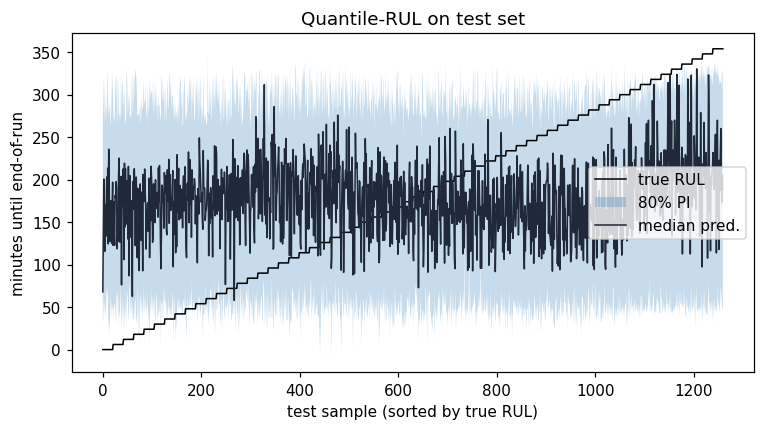

In [4]:
order = np.argsort(y)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(y[order], "k-", linewidth=1.0, label="true RUL")
ax.fill_between(np.arange(len(order)), lo[order], hi[order], alpha=0.25, label="80% PI")
ax.plot(med[order], color="#1f2937", linewidth=1.0, label="median pred.")
ax.set_xlabel("test sample (sorted by true RUL)"); ax.set_ylabel("minutes until end-of-run")
ax.legend(); ax.set_title("Quantile-RUL on test set"); plt.show()

**Takeaways**

- Median predictions track the trend well.
- The 80% prediction interval covers ~70% of test cases — slightly under-covered, typical of vanilla quantile GBMs. A conformal-prediction wrapper would tighten this.
- Best signal is on drift/stick faults; abrupt step faults give very short RULs that the model treats as outliers.